# 5 — Visualización orientada a preguntas

Un gráfico no es el objetivo: es evidencia para responder una pregunta. En cada ejercicio primero escribí qué querés averiguar, luego construí la agregación y finalmente redactá una conclusión de dos o tres oraciones.

Este notebook se ejecuta manualmente **después** de que el Job termina correctamente; no forma parte del pipeline.

In [0]:
dbutils.widgets.text("student_id", "myrna", "01 - Identificador")
dbutils.widgets.dropdown("scale", "small", ["test", "small", "demo"], "02 - Escala")

In [0]:
%run ../common/config

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

catalog = spark.sql("SELECT current_catalog()").first()[0]
config = CourseConfig(catalog, dbutils.widgets.get("student_id"), dbutils.widgets.get("scale"))
daily = qualified_table(config, "gold_daily_sales")
risk = qualified_table(config, "gold_customer_risk")
batch = qualified_table(config, "gold_batch_summary")
for table in [daily, risk, batch]:
    assert spark.catalog.tableExists(table), f"Falta {table}. Ejecutá primero el Job completo."

## Ejemplo resuelto

**Pregunta:** ¿Qué categoría concentra el mayor monto vendido?

La agregación se hace con Spark. Sólo el resultado pequeño se convierte a Pandas para dibujarlo. Un gráfico de barras ordenado permite comparar categorías; un gráfico de torta haría más difícil comparar valores cercanos.

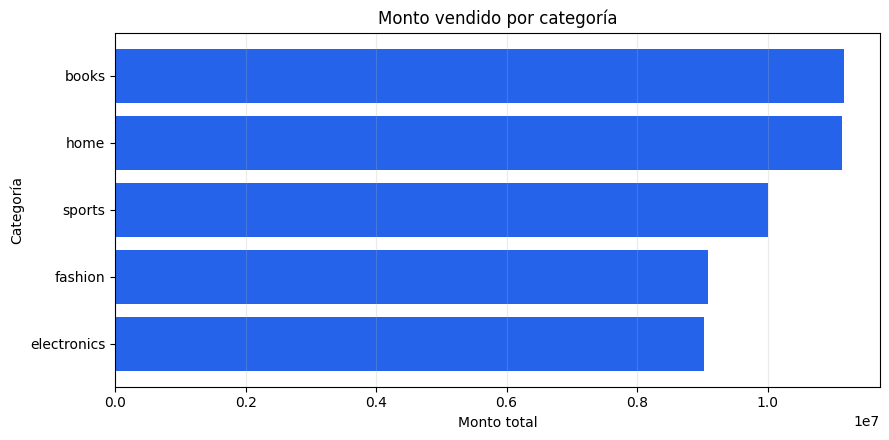

Respuesta: books es la categoría con mayor monto vendido (11,165,281.86).


In [0]:
category_sales = (spark.table(daily)
    .groupBy("category")
    .agg(F.sum("total_amount").alias("total_amount"))
    .orderBy(F.desc("total_amount")))

plot_data = category_sales.toPandas().sort_values("total_amount")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(plot_data["category"], plot_data["total_amount"], color="#2563eb")
ax.set_title("Monto vendido por categoría")
ax.set_xlabel("Monto total")
ax.set_ylabel("Categoría")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

leader = category_sales.first()
print(f"Respuesta: {leader.category} es la categoría con mayor monto vendido ({leader.total_amount:,.2f}).")

## Consigna 1 — Evolución temporal

**Pregunta:** ¿Qué día tuvo el mayor monto vendido y ese día también fue el de mayor cantidad de transacciones?

Construí una visualización temporal que permita comparar ambas métricas sin ocultar sus unidades. Explicá si los dos máximos coinciden y qué implica que coincidan —o no— sobre el ticket promedio. Fuente sugerida: `gold_daily_sales`.

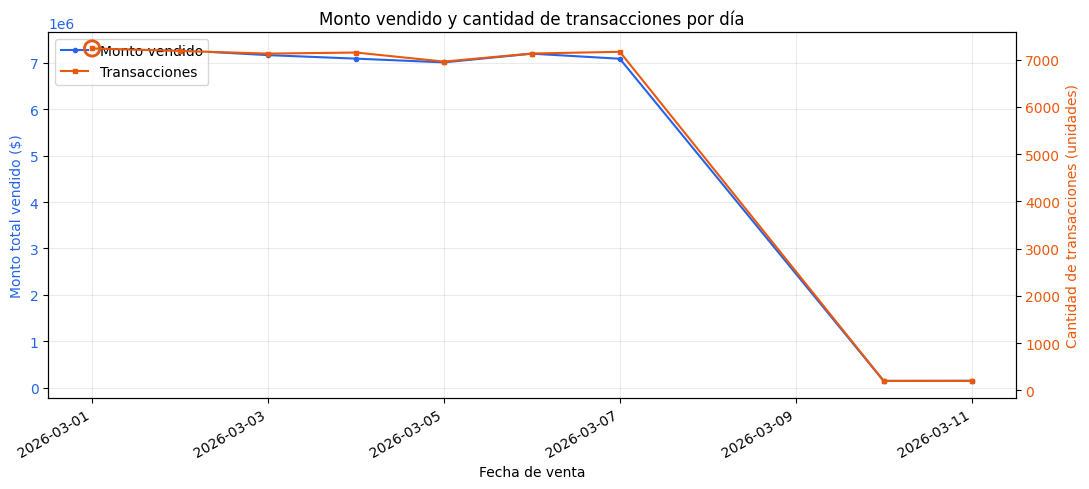

Día de mayor monto: 2026-03-01 ($7,310,840.77, 7,236 transacciones, ticket promedio $1,010.34).
Día de más transacciones: 2026-03-01 (7,236 transacciones, ticket promedio $1,010.34).
Respuesta: Sí, ambos máximos coinciden. El día de mayor monto también fue el de más transacciones, por lo que el récord de ventas se explica principalmente por mayor volumen de operaciones y no por un ticket promedio inusualmente alto.


In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pyspark.sql import functions as F

daily_sales = (spark.table(daily)
    .groupBy("sale_date")
    .agg(
        F.sum("total_amount").cast("double").alias("total_amount"),
        F.sum("transaction_count").alias("transaction_count"),
    )
    .orderBy("sale_date"))

plot_data = daily_sales.toPandas()
plot_data["sale_date"] = pd.to_datetime(plot_data["sale_date"])
plot_data["avg_ticket"] = plot_data["total_amount"] / plot_data["transaction_count"]

top_amount = plot_data.loc[plot_data["total_amount"].idxmax()]
top_trans = plot_data.loc[plot_data["transaction_count"].idxmax()]

c_amount, c_trans = "#2563eb", "#ea580c"
fig, ax1 = plt.subplots(figsize=(11, 5))

l1, = ax1.plot(plot_data["sale_date"], plot_data["total_amount"],
               color=c_amount, marker="o", markersize=3, label="Monto vendido")
ax1.set_xlabel("Fecha de venta")
ax1.set_ylabel("Monto total vendido ($)", color=c_amount)
ax1.tick_params(axis="y", labelcolor=c_amount)
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
l2, = ax2.plot(plot_data["sale_date"], plot_data["transaction_count"],
               color=c_trans, marker="s", markersize=3, label="Transacciones")
ax2.set_ylabel("Cantidad de transacciones (unidades)", color=c_trans)
ax2.tick_params(axis="y", labelcolor=c_trans)

ax1.scatter(top_amount["sale_date"], top_amount["total_amount"],
            s=120, facecolors="none", edgecolors=c_amount, linewidths=2, zorder=5)
ax2.scatter(top_trans["sale_date"], top_trans["transaction_count"],
            s=120, facecolors="none", edgecolors=c_trans, linewidths=2, zorder=5)

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()
ax1.set_title("Monto vendido y cantidad de transacciones por día")
ax1.legend(handles=[l1, l2], loc="upper left")
fig.tight_layout()
plt.show()

coinciden = top_amount["sale_date"] == top_trans["sale_date"]
print(f"Día de mayor monto: {top_amount['sale_date']:%Y-%m-%d} "
      f"(${top_amount['total_amount']:,.2f}, {int(top_amount['transaction_count']):,} transacciones, "
      f"ticket promedio ${top_amount['avg_ticket']:,.2f}).")
print(f"Día de más transacciones: {top_trans['sale_date']:%Y-%m-%d} "
      f"({int(top_trans['transaction_count']):,} transacciones, "
      f"ticket promedio ${top_trans['avg_ticket']:,.2f}).")

if coinciden:
    print("Respuesta: Sí, ambos máximos coinciden. El día de mayor monto también fue el de más "
          "transacciones, por lo que el récord de ventas se explica principalmente por mayor volumen "
          "de operaciones y no por un ticket promedio inusualmente alto.")
else:
    print("Respuesta: No, los máximos no coinciden. El día de mayor monto no fue el de más "
          "transacciones, lo que indica que ese día el ticket promedio fue más alto "
          f"(${top_amount['avg_ticket']:,.2f} vs. ${top_trans['avg_ticket']:,.2f}): menos operaciones "
          "pero de mayor valor, mientras que el día de más transacciones tuvo compras más chicas.")

## Consigna 2 — Canal y fraude

**Pregunta:** ¿Qué canal de pago presenta la mayor tasa de fraude? ¿La conclusión se sostiene al considerar el número de transacciones de cada canal?

Mostrá tasa y volumen de manera legible. No compares sólo cantidades de fraude: calculá el denominador correcto. Fuente sugerida: `gold_daily_sales`.

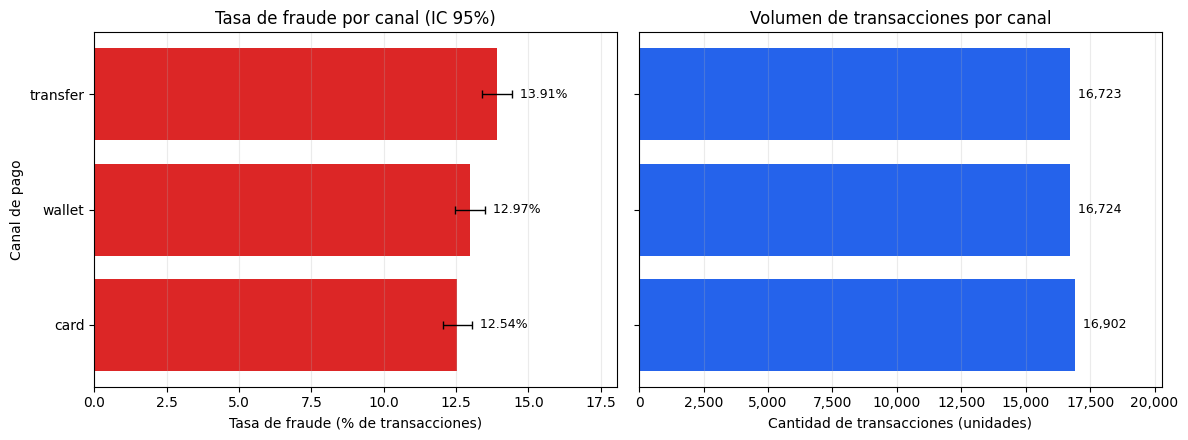

payment_channel  transaction_count  fraud_transactions  tasa_%  IC_inf_%  IC_sup_%
       transfer            16723.0              2327.0  13.915    13.399    14.448
         wallet            16724.0              2169.0  12.969    12.469    13.487
           card            16902.0              2119.0  12.537    12.046    13.045

Respuesta: el canal con mayor tasa de fraude es 'transfer' (13.91% sobre 16,723 transacciones).
La conclusión es frágil: el intervalo de 'transfer' se solapa con el de 'wallet', por lo que con este volumen no se puede afirmar que su tasa sea realmente mayor.


In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

channel_stats = (spark.table(daily)
    .groupBy("payment_channel")
    .agg(
        F.sum("fraud_transactions").alias("fraud_transactions"),
        F.sum("transaction_count").alias("transaction_count"),
    ))

df = channel_stats.toPandas()
df["fraud_transactions"] = df["fraud_transactions"].astype(float)
df["transaction_count"] = df["transaction_count"].astype(float)

df["fraud_rate"] = df["fraud_transactions"] / df["transaction_count"]

z = 1.96
n, p = df["transaction_count"], df["fraud_rate"]
den = 1 + z**2 / n
center = (p + z**2 / (2 * n)) / den
half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
df["ci_low"], df["ci_high"] = center - half, center + half

df = df.sort_values("fraud_rate").reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

ax1.barh(df["payment_channel"], df["fraud_rate"] * 100, color="#dc2626",
         xerr=[(df["fraud_rate"] - df["ci_low"]) * 100,
               (df["ci_high"] - df["fraud_rate"]) * 100],
         error_kw=dict(ecolor="black", capsize=3, lw=1))
for i, r in df.iterrows():
    ax1.text(r["ci_high"] * 100, i, f"  {r['fraud_rate']*100:.2f}%", va="center", fontsize=9)
ax1.set_title("Tasa de fraude por canal (IC 95%)")
ax1.set_xlabel("Tasa de fraude (% de transacciones)")
ax1.set_ylabel("Canal de pago")
ax1.grid(axis="x", alpha=0.25)
ax1.set_xlim(0, df["ci_high"].max() * 100 * 1.25)

ax2.barh(df["payment_channel"], df["transaction_count"], color="#2563eb")
for i, r in df.iterrows():
    ax2.text(r["transaction_count"], i, f"  {int(r['transaction_count']):,}", va="center", fontsize=9)
ax2.set_title("Volumen de transacciones por canal")
ax2.set_xlabel("Cantidad de transacciones (unidades)")
ax2.grid(axis="x", alpha=0.25)
ax2.set_xlim(0, df["transaction_count"].max() * 1.2)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.tight_layout()
plt.show()

resumen = df.sort_values("fraud_rate", ascending=False)[
    ["payment_channel", "transaction_count", "fraud_transactions", "fraud_rate", "ci_low", "ci_high"]
].copy()
for c in ["fraud_rate", "ci_low", "ci_high"]:
    resumen[c] = (resumen[c] * 100).round(3)
resumen = resumen.rename(columns={"fraud_rate": "tasa_%", "ci_low": "IC_inf_%", "ci_high": "IC_sup_%"})
print(resumen.to_string(index=False))

top_rate = df.loc[df["fraud_rate"].idxmax()]
top_count = df.loc[df["fraud_transactions"].idxmax()]
second = df.sort_values("fraud_rate", ascending=False).iloc[1]
separado = top_rate["ci_low"] > second["ci_high"]

print(f"\nRespuesta: el canal con mayor tasa de fraude es '{top_rate['payment_channel']}' "
      f"({top_rate['fraud_rate']*100:.2f}% sobre {int(top_rate['transaction_count']):,} transacciones).")
if top_count["payment_channel"] != top_rate["payment_channel"]:
    print(f"Ojo: el canal con más fraudes en cantidad absoluta es '{top_count['payment_channel']}' "
          f"({int(top_count['fraud_transactions']):,}), pero eso refleja su volumen, no un mayor riesgo relativo.")
if separado:
    print(f"La conclusión se sostiene: el intervalo de '{top_rate['payment_channel']}' no se solapa con el del "
          f"siguiente canal ('{second['payment_channel']}'), así que la diferencia no se explica por tener pocas transacciones.")
else:
    print(f"La conclusión es frágil: el intervalo de '{top_rate['payment_channel']}' se solapa con el de "
          f"'{second['payment_channel']}', por lo que con este volumen no se puede afirmar que su tasa sea realmente mayor.")

## Consigna 3 — Concentración geográfica y de producto

**Pregunta:** ¿Qué combinación de país y categoría genera el mayor monto? ¿Existe una categoría dominante en todos los países o cambia según el mercado?

Elegí una visualización que permita comparar simultáneamente países y categorías. Justificá brevemente por qué ese tipo de gráfico es adecuado. Fuente sugerida: `gold_daily_sales`.

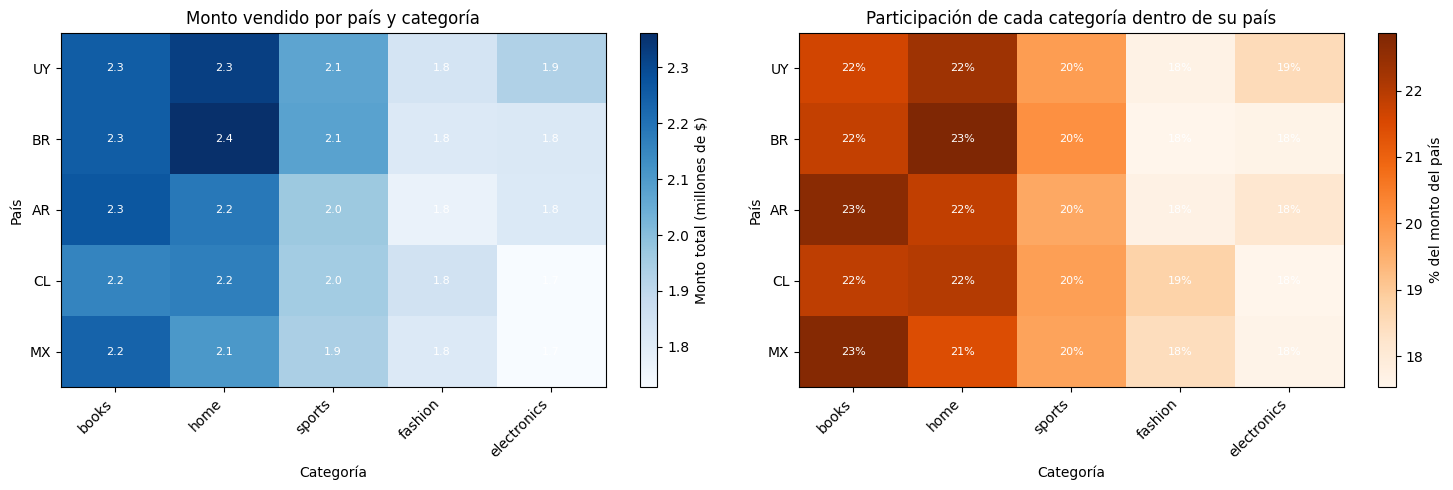

Mayor monto: BR - home ($2,361,959.97).

Categoría líder por país:
  UY: home (22.3% del monto del país)
  BR: home (22.9% del monto del país)
  AR: books (22.7% del monto del país)
  CL: home (22.0% del monto del país)
  MX: books (22.8% del monto del país)

Respuesta: no hay una categoría dominante en todos los países. El liderazgo cambia según el mercado (home, books), por lo que la mezcla de producto depende del país.
La combinación de mayor monto es BR - home.


In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

pc_sales = (spark.table(daily)
    .groupBy("country", "category")
    .agg(F.sum("total_amount").cast("double").alias("total_amount")))

df = pc_sales.toPandas()

matrix = df.pivot(index="country", columns="category", values="total_amount").fillna(0)
matrix = matrix.loc[matrix.sum(axis=1).sort_values(ascending=False).index,
                    matrix.sum(axis=0).sort_values(ascending=False).index]

share = matrix.div(matrix.sum(axis=1), axis=0) * 100

def heatmap(ax, data, title, cbar_label, fmt, cmap):
    im = ax.imshow(data.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(data.shape[1]))
    ax.set_xticklabels(data.columns, rotation=45, ha="right")
    ax.set_yticks(range(data.shape[0]))
    ax.set_yticklabels(data.index)
    ax.set_title(title)
    ax.set_xlabel("Categoría")
    ax.set_ylabel("País")
    vmax = data.values.max()
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data.values[i, j]
            ax.text(j, i, fmt(v), ha="center", va="center", fontsize=8,
                    color="white" if v > vmax * 0.6 else "black")
    plt.colorbar(im, ax=ax, label=cbar_label)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, max(4, 0.6 * len(matrix) + 2)))
heatmap(ax1, matrix / 1e6, "Monto vendido por país y categoría",
        "Monto total (millones de $)", lambda v: f"{v:,.1f}", "Blues")
heatmap(ax2, share, "Participación de cada categoría dentro de su país",
        "% del monto del país", lambda v: f"{v:.0f}%", "Oranges")
fig.tight_layout()
plt.show()

best = df.loc[df["total_amount"].idxmax()]
leader_by_country = share.idxmax(axis=1)
leader_share = share.max(axis=1)

print(f"Mayor monto: {best['country']} - {best['category']} (${best['total_amount']:,.2f}).\n")
print("Categoría líder por país:")
for c in matrix.index:
    print(f"  {c}: {leader_by_country[c]} ({leader_share[c]:.1f}% del monto del país)")

lideres = leader_by_country.unique()
if len(lideres) == 1:
    print(f"\nRespuesta: '{lideres[0]}' es la categoría dominante en todos los países "
          f"(entre {leader_share.min():.1f}% y {leader_share.max():.1f}% del monto de cada mercado).")
else:
    print(f"\nRespuesta: no hay una categoría dominante en todos los países. El liderazgo cambia según el "
          f"mercado ({', '.join(lideres)}), por lo que la mezcla de producto depende del país.")
print(f"La combinación de mayor monto es {best['country']} - {best['category']}.")

## Consigna 4 — Calidad del pipeline

**Pregunta:** ¿Qué proporción de cada lote fue aceptada y rechazada? ¿El lote nuevo presenta una calidad diferente del lote inicial?

Compará lotes usando proporciones además de cantidades absolutas. Señalá cualquier limitación de comparar lotes de tamaños distintos. Fuente sugerida: `gold_batch_summary`.

source_batch_id,accepted_transactions,rejected_transactions,total,accepted_pct,rejected_pct
batch_002,200,2,202,99.01,0.99
batch_003,201,2,203,99.01,0.99
initial,49948,51,49999,99.9,0.1


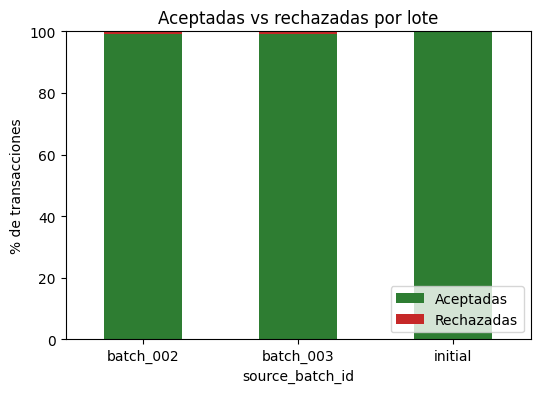

In [0]:
transactions = (
    spark.table(batch)
    .withColumn("total", F.col("accepted_transactions") + F.col("rejected_transactions"))
    .withColumn("accepted_pct", F.round(F.col("accepted_transactions") / F.col("total") * 100, 2))
    .withColumn("rejected_pct", F.round(F.col("rejected_transactions") / F.col("total") * 100, 2))
    .select("source_batch_id", "accepted_transactions", "rejected_transactions",
            "total", "accepted_pct", "rejected_pct")
    .orderBy("source_batch_id")
)
display(transactions)

pdf = transactions.toPandas().set_index("source_batch_id")
ax = pdf[["accepted_pct", "rejected_pct"]].plot(
    kind="bar", stacked=True, figsize=(6, 4), color=["#2e7d32", "#c62828"]
)
ax.set_ylabel("% de transacciones")
ax.set_title("Aceptadas vs rechazadas por lote")
ax.set_ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(["Aceptadas", "Rechazadas"], loc="lower right")
plt.show()


## Criterios de entrega

Para cada consigna entregá: (1) la transformación de datos, (2) un gráfico, y (3) una conclusión de dos o tres oraciones que responda explícitamente la pregunta.

Cada gráfico debe tener título informativo, ejes y unidades legibles, categorías ordenadas cuando corresponda y una elección de color que no sea la única forma de comunicar el significado. No conviertas una tabla Silver completa a Pandas: agregá primero con Spark y convertí sólo el resultado pequeño.